## Training Notebook - 1
Notebook for training fast-r-cnn on the new dataset created by first subsetting bdd100k, and then dividing in 2 parts:

control: 'clear' weather and 'good' visibility

stress: everything remaining was in stress

In [ ]:
!nvidia-smi

Mon Mar 30 04:20:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   29C    P0             47W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!pip install torchmetrics[detection]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.6 MB/s eta 0:00:00


In [ ]:
import torch
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_properties(0))

NVIDIA RTX PRO 6000 Blackwell Server Edition
_CudaDeviceProperties(name='NVIDIA RTX PRO 6000 Blackwell Server Edition', major=12, minor=0, total_memory=97250MB, multi_processor_count=188, uuid=38fa92c9-8698-d11c-06ea-b9465cd0716b, pci_bus_id=5, pci_device_id=0, pci_domain_id=0, L2_cache_size=128MB)


In [ ]:
import os, json

import torchvision.transforms.functional as F
import random

import torch
from PIL import Image
from torch.utils.data import Dataset,DataLoader,Subset

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from torchvision.models.detection import FasterRCNN
from torchvision.datasets import CocoDetection
from torchvision.ops import box_iou

import torch.optim as optim

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from zipfile import ZipFile
import shutil
from tqdm import tqdm

## Dataset loading

In [ ]:


# Paths
drive_zip_path = '/content/drive/MyDrive/Seminar-XAI-Project/new_dataset.zip'
local_zip_path = "/content/new_dataset.zip"
local_extract_path = "/content/new_dataset"

# Step 1: Copy zip from Drive → local runtime
if not os.path.exists(local_zip_path):
    print("Copying zip file to local runtime...")
    shutil.copy(drive_zip_path, local_zip_path)
    print("Copy complete.")
else:
    print("Zip already exists in local runtime. Skipping copy.")

# Step 2: Extract locally
if not os.path.exists(local_extract_path):
    print("Extracting locally...")
    with ZipFile(local_zip_path, 'r') as zip_ref:
        for file_info in tqdm(zip_ref.infolist(), desc="Extracting files"):
            zip_ref.extract(file_info, local_extract_path)
    print("Extraction complete.")
else:
    print("Already extracted locally. Skipping extraction.")

Copying zip file to local runtime...
Copy complete.
Extracting locally...


Extracting files: 100%|██████████| 26618/26618 [00:03<00:00, 7029.78it/s] 

Extraction complete.


In [ ]:
DATASET_ROOT = "/content/new_dataset"

CONTROL_TRAIN_IMGS   = f"{DATASET_ROOT}/control/images/train"
CONTROL_VAL_IMGS     = f"{DATASET_ROOT}/control/images/val"
CONTROL_TEST_IMGS    = f"{DATASET_ROOT}/control/images/test"

CONTROL_TRAIN_LABELS = f"{DATASET_ROOT}/control/labels/train"
CONTROL_VAL_LABELS   = f"{DATASET_ROOT}/control/labels/val"
CONTROL_TEST_LABELS  = f"{DATASET_ROOT}/control/labels/test"

STRESS_TRAIN_IMGS    = f"{DATASET_ROOT}/stress/images/train"
STRESS_VAL_IMGS      = f"{DATASET_ROOT}/stress/images/val"
STRESS_TEST_IMGS     = f"{DATASET_ROOT}/stress/images/test"

STRESS_TRAIN_LABELS  = f"{DATASET_ROOT}/stress/labels/train"
STRESS_VAL_LABELS    = f"{DATASET_ROOT}/stress/labels/val"
STRESS_TEST_LABELS   = f"{DATASET_ROOT}/stress/labels/test"

In [ ]:
import torchvision.transforms.functional as F
import random

class ToTensor:
    def __call__(self, img, target):
        return F.to_tensor(img), target


class RandomHorizontalFlip:
    def __init__(self, prob):
        self.prob = prob

    def __call__(self, img, target):
        if random.random() < self.prob:
            img = F.hflip(img)

            W, _ = img.size  # PIL image size
            boxes = target["boxes"]

            if boxes.shape[0] > 0:
                boxes[:, [0, 2]] = W - boxes[:, [2, 0]]
                target["boxes"] = boxes

        return img, target


class Compose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, target):
        for t in self.transforms:
            img, target = t(img, target)
        return img, target


class RandomVerticalFlip:
    def __init__(self, prob=0.5):
        self.prob = prob
    def __call__(self, img, target):
        if random.random() < self.prob:
            img = F.vflip(img)
            W, H = img.size
            boxes = target["boxes"]
            if boxes.shape[0] > 0:
                boxes[:, [1, 3]] = H - boxes[:, [3, 1]]
                target["boxes"] = boxes
        return img, target

class ColorJitter:
    def __init__(self, brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1):
        self.transform = torchvision.transforms.ColorJitter(brightness, contrast, saturation, hue)
    def __call__(self, img, target):
        img = self.transform(img)
        return img, target

class RandomScale:
    def __init__(self, scales=(0.8, 1.2)):
        self.scales = scales
    def __call__(self, img, target):
        scale = random.uniform(*self.scales)
        W, H = img.size
        new_W, new_H = int(W*scale), int(H*scale)
        img = img.resize((new_W, new_H))
        boxes = target["boxes"]
        if boxes.shape[0] > 0:
            boxes = boxes * scale
            target["boxes"] = boxes
        return img, target
def get_transform(train):
    transforms = []
    if train:
        transforms.append(RandomHorizontalFlip(0.5))
        transforms.append(RandomVerticalFlip(0.2))
        transforms.append(RandomScale((0.8, 1.2)))
        transforms.append(ColorJitter())
    transforms.append(ToTensor())
    return Compose(transforms)

In [ ]:


# Map the string categories from your JSON to integers
# LABEL_MAP = {"background": 0, "pedestrian": 1, "car": 2, "truck": 3, "bus": 3, "rider": 1, "traffic light": 4, "traffic sign": 5}
LABEL_MAP = {"background": 0, "car": 1, "traffic light": 2, "traffic sign": 3}

class PerImageJSONDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir   = img_dir
        self.label_dir = label_dir
        self.transform = transform

        self.samples = []
        for fname in sorted(os.listdir(img_dir)):
            if not fname.lower().endswith(('.jpg', '.png', '.jpeg')):
                continue
            stem = os.path.splitext(fname)[0]
            json_path = os.path.join(label_dir, stem + ".json")
            if os.path.exists(json_path):
                self.samples.append((fname, json_path))

        print(f"Loaded {len(self.samples)} matched image-label pairs from {img_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
          img_fname, json_path = self.samples[idx]
          img_path = os.path.join(self.img_dir, img_fname)
          img = Image.open(img_path).convert("RGB")
          W, H = img.size

          with open(json_path) as f:
              data = json.load(f)

          boxes, labels = [], []

          # Update logic: Navigate the 'frames' -> 'objects' structure
          frames = data.get("frames", [])
          for frame in frames:
              for obj in frame.get("objects", []):
                  cat_name = obj.get("category")
                  label_id = LABEL_MAP.get(cat_name)
                  if label_id is None:
                    continue

                  box = obj.get("box2d")
                  if not box:
                      continue

                  x1, y1, x2, y2 = float(box['x1']), float(box['y1']), float(box['x2']), float(box['y2'])

                  # Clamp to image size
                  x1 = max(0.0, min(x1, W))
                  y1 = max(0.0, min(y1, H))
                  x2 = max(0.0, min(x2, W))
                  y2 = max(0.0, min(y2, H))

                  if x2 - x1 < 1.0 or y2 - y1 < 1.0:
                      continue

                  boxes.append([x1, y1, x2, y2])
                  labels.append(label_id)

          if len(boxes) == 0:
              boxes  = torch.zeros((0, 4), dtype=torch.float32)
              labels = torch.zeros((0,),   dtype=torch.int64)
          else:
              boxes  = torch.tensor(boxes,  dtype=torch.float32)
              labels = torch.tensor(labels, dtype=torch.int64)

          target = {
              "boxes":    boxes,
              "labels":   labels,
              "image_id": torch.tensor([idx]),
          }

          if self.transform:
              img, target = self.transform(img, target)

          return img, target

In [ ]:
# Re-initialize datasets with the new logic
control_train_ds = PerImageJSONDataset(CONTROL_TRAIN_IMGS, CONTROL_TRAIN_LABELS, get_transform(True))
control_val_ds   = PerImageJSONDataset(CONTROL_VAL_IMGS,   CONTROL_VAL_LABELS,   get_transform(False))
control_test_ds  = PerImageJSONDataset(CONTROL_TEST_IMGS,  CONTROL_TEST_LABELS,  get_transform(False))
stress_test_ds   = PerImageJSONDataset(STRESS_TEST_IMGS,   STRESS_TEST_LABELS,   get_transform(False))



Loaded 1973 matched image-label pairs from /content/new_dataset/control/images/train
Loaded 561 matched image-label pairs from /content/new_dataset/control/images/val
Loaded 448 matched image-label pairs from /content/new_dataset/control/images/test
Loaded 1552 matched image-label pairs from /content/new_dataset/stress/images/test


In [ ]:
from collections import Counter


def get_class_distribution(dataset):
    counter = Counter()
    total = 0
    # with tqdm
    for _, target in tqdm(dataset):
        labels = target['labels']
        counter.update(labels.tolist())
        total += len(labels)

    print(f"Total objects: {total}")
    for cls, count in counter.items():
        print(f"Class {cls}: {count} ({count/total*100:.2f}%)")

    return counter


get_class_distribution(control_train_ds)

100%|██████████| 1973/1973 [04:28<00:00,  7.34it/s]

Total objects: 31893
Class 2: 4918 (15.42%)
Class 3: 6613 (20.73%)
Class 1: 20362 (63.84%)


Counter({2: 4918, 3: 6613, 1: 20362})

In [ ]:
BATCH_SIZE=32

# Re-create loaders
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(control_train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(control_val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(control_test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

stress_test_loader=DataLoader(stress_test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


In [ ]:
get_class_distribution(stress_test_ds)

100%|██████████| 1552/1552 [00:04<00:00, 375.09it/s]

Total objects: 24242
Class 2: 4889 (20.17%)
Class 1: 14137 (58.32%)
Class 3: 5216 (21.52%)


Counter({2: 4889, 1: 14137, 3: 5216})

In [ ]:
get_class_distribution(stress_test_ds)

Image shape : torch.Size([3, 654, 1164])
Boxes       : tensor([[ 441.3954,  348.1711,  469.4629,  376.2386],
        [ 614.0330,  299.4044,  687.2090,  420.6963],
        [ 649.1174,  327.4720,  803.4889,  447.7614],
        [ 737.3297,  358.5467, 1086.1689,  542.9905],
        [ 458.6591,  305.4189,  628.0668,  470.8169],
        [ 378.4662,  334.4889,  448.6350,  399.6456],
        [   1.5593,  353.5347,   38.6485,  484.8506],
        [ 718.2839,  258.3055,  767.4020,  327.4720],
        [1021.0122,  222.1073, 1057.0991,  286.2617],
        [1020.0098,  161.9626, 1054.0918,  227.1194]])
Labels      : tensor([1, 1, 1, 1, 1, 1, 1, 3, 3, 3])
Any NaN?    : False


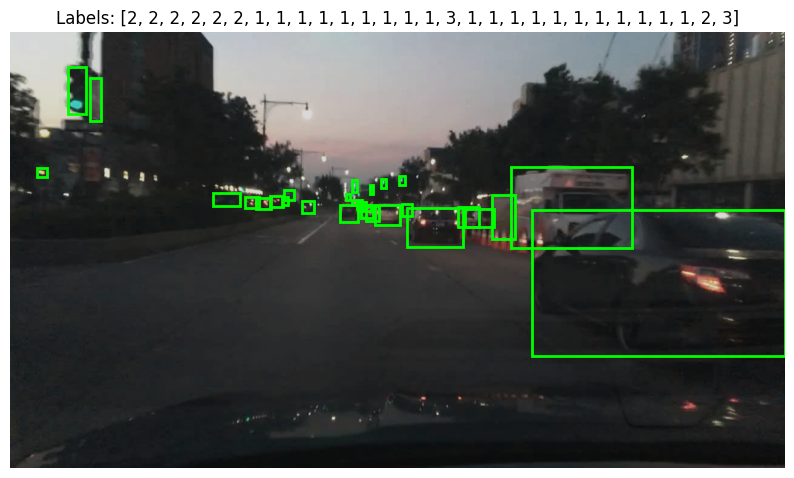

✅ If green boxes appear on objects, dataset is correct


In [ ]:


device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

imgs, targets = next(iter(train_loader))
print("Image shape :", imgs[0].shape)
print("Boxes       :", targets[0]["boxes"])
print("Labels      :", targets[0]["labels"])
print("Any NaN?    :", torch.isnan(imgs[0]).any().item())
idx=1
img_np = imgs[idx].permute(1,2,0).numpy()
fig, ax = plt.subplots(figsize=(10,6))
ax.imshow(img_np)
for box in targets[idx]["boxes"]:
    x1,y1,x2,y2 = box.tolist()
    ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                  linewidth=2, edgecolor='lime', facecolor='none'))
plt.title(f"Labels: {targets[idx]['labels'].tolist()}")
plt.axis('off'); plt.show()
print("✅ If green boxes appear on objects, dataset is correct")

## Model and training

In [ ]:


def get_model(num_classes):
    # Load a model pre-trained on COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

    # Replace the classifier with a new one, that has 'num_classes' which includes the background
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


In [ ]:
num_classes=4
model = get_model(num_classes=num_classes)
model.to(device)
print("Model initialized and moved to", device)

In [ ]:
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision

@torch.no_grad()
def evaluate_detection_map(model, data_loader, device):
    """
    Evaluate a detection model using mAP (mean Average Precision)
    Args:
        model: torch detection model
        data_loader: DataLoader with batches of (imgs, targets)
        device: cuda or cpu
    """
    model.eval()
    metric = MeanAveragePrecision(class_metrics=True)

    for imgs, targets in data_loader:
        imgs = [img.to(device) for img in imgs]
        # keep targets on CPU for torchmetrics
        targets_cpu = [{k: v.cpu() for k,v in t.items()} for t in targets]

        outputs = model(imgs)
        # move outputs to CPU
        outputs_cpu = [{k: v.cpu() for k,v in out.items()} for out in outputs]

        metric.update(outputs_cpu, targets_cpu)

    results = metric.compute()
    print("mAP @ IoU=0.50:0.95 ->", results["map"].item())
    print("mAP @ IoU=0.50      ->", results["map_50"].item())
    print("mAP @ IoU=0.75      ->", results["map_75"].item())
    print("mAP per class:", results["map_per_class"].tolist())
    return results

In [ ]:
import os

checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)



In [ ]:

from tqdm import tqdm
model.train()
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15
)
# Mixed precision
scaler = torch.cuda.amp.GradScaler()

# num_epochs = 5
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}')

    for imgs, targets in pbar:
        imgs = list(img.to(device) for img in imgs)
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]

        # loss_dict = model(imgs, targets)
        # losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        # Mixed precision
        with torch.cuda.amp.autocast():
            loss_dict = model(imgs, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += losses.item()
    scheduler.step()  # step at the end of epoch

    if (epoch+1)%3==0:
      torch.save({
          "epoch": epoch + 1,
          "model_state_dict": model.state_dict(),
          "optimizer_state_dict": optimizer.state_dict(),
          "scheduler_state_dict": scheduler.state_dict(),
          "scaler_state_dict": scaler.state_dict(),
      }, os.path.join(checkpoint_dir, f"model_epoch{epoch+1}.pth"))

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss/len(train_loader)}")

    # Optional: run validation every epoch
    evaluate_detection_map(model, val_loader, device=device)

/tmp/ipykernel_1246/1089234545.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1:   0%|          | 0/62 [00:00<?, ?it/s]/tmp/ipykernel_1246/1089234545.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1: 100%|██████████| 62/62 [02:11<00:00,  2.13s/it]


Epoch 1/20, Train Loss: 1.235727306335203
mAP @ IoU=0.50:0.95 -> 0.18554461002349854
mAP @ IoU=0.50      -> 0.40731438994407654
mAP @ IoU=0.75      -> 0.15115152299404144
mAP per class: [0.33846887946128845, 0.08304089307785034, 0.1351240575313568]


Epoch 2: 100%|██████████| 62/62 [02:12<00:00,  2.13s/it]


Epoch 2/20, Train Loss: 0.9670071092344099
mAP @ IoU=0.50:0.95 -> 0.22777055203914642
mAP @ IoU=0.50      -> 0.484202116727829
mAP @ IoU=0.75      -> 0.18384991586208344
mAP per class: [0.3631451427936554, 0.12971411645412445, 0.1904524266719818]


Epoch 3: 100%|██████████| 62/62 [02:11<00:00,  2.13s/it]


...

Epoch 18/20, Train Loss: 0.8182345830625103
mAP @ IoU=0.50:0.95 -> 0.27503275871276855
mAP @ IoU=0.50      -> 0.5798354148864746
mAP @ IoU=0.75      -> 0.22831220924854279
mAP per class: [0.39949262142181396, 0.16830919682979584, 0.25729644298553467]


Epoch 19: 100%|██████████| 62/62 [02:12<00:00,  2.13s/it]


Epoch 19/20, Train Loss: 0.8199456987842437
mAP @ IoU=0.50:0.95 -> 0.2762399911880493
mAP @ IoU=0.50      -> 0.5795673131942749
mAP @ IoU=0.75      -> 0.2302185297012329
mAP per class: [0.4003047049045563, 0.16999873518943787, 0.2584165632724762]


Epoch 20: 100%|██████████| 62/62 [02:11<00:00,  2.11s/it]


Epoch 20/20, Train Loss: 0.8191685176664784
mAP @ IoU=0.50:0.95 -> 0.27648377418518066
mAP @ IoU=0.50      -> 0.5793993473052979
mAP @ IoU=0.75      -> 0.228560671210289
mAP per class: [0.3986912965774536, 0.17237122356891632, 0.25838878750801086]


## Load Model

In [ ]:


# Paths
saved_model_path = '/content/drive/MyDrive/Seminar-XAI-Project/model_epoch18.pth'
local_model_path = "/content/model_epoch18.pth"


# Step 1: Copy model from Drive → local runtime
if not os.path.exists(local_model_path):
    print("Copying saved model to local runtime...")
    shutil.copy(saved_model_path, local_model_path)
    print("Copy complete.")
else:
    print("Model already exists in local runtime. Skipping copy.")


Copying saved model to local runtime...
Copy complete.


In [ ]:


# 1. Recreate model architecture
num_classes=4
model = get_model(num_classes=num_classes)


# 2. Load checkpoint
checkpoint = torch.load("/content/model_epoch18.pth", map_location="cuda")  # or "cuda"

# 3. Load weights
model.load_state_dict(checkpoint["model_state_dict"])

# 4. Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 5. Set to evaluation mode
model.eval()

Image shape : torch.Size([3, 720, 1280])
Boxes       : tensor([[ 477.8898,  343.1324,  489.1196,  356.8577],
        [ 526.5522,  344.3801,  535.2865,  360.6009],
        [ 432.9706,  368.0874,  445.4482,  378.0695],
        [ 560.2416,  366.8397,  570.2236,  375.5740],
        [ 485.3763,  380.5650,  506.5881,  391.7948],
        [ 484.1286,  361.8487,  496.6061,  375.5740],
        [ 549.0118,  361.8487,  557.7460,  374.3262],
        [ 416.7498,  380.5650,  437.9617,  406.7678],
        [ 395.5380,  388.0515,  415.5021,  410.5111],
        [ 366.8397,  388.0515,  396.7858,  420.4931],
        [ 316.9295,  384.3083,  359.3531,  427.9796],
        [ 249.5508,  386.8037,  325.6638,  436.7139],
        [ 152.2260,  379.3172,  238.3210,  461.6690],
        [  64.8832,  385.5560,  167.1990,  475.3943],
        [   0.0000,  365.5919,   72.3697,  491.6151],
        [ 515.3224,  373.0785,  581.4534,  430.4752],
        [ 581.4534,  376.8217,  608.9040,  400.5291],
        [ 601.4174,  376.82

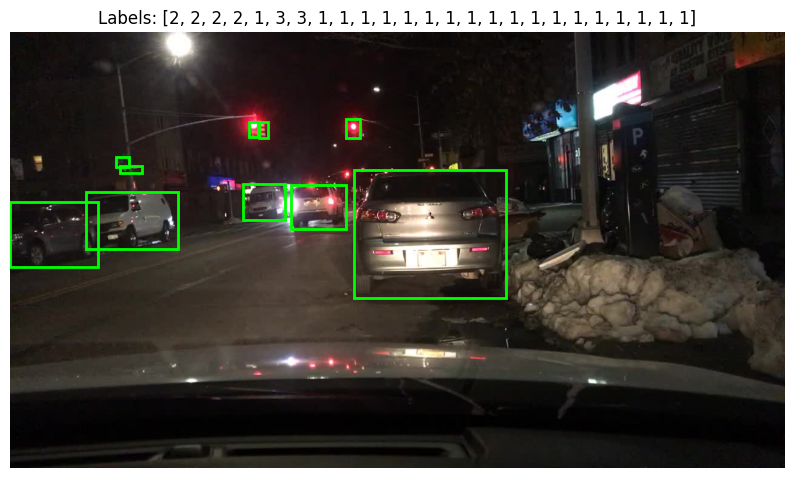

✅ If green boxes appear on objects, dataset is correct


In [ ]:


device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

imgs, targets = next(iter(stress_test_loader))
print("Image shape :", imgs[0].shape)
print("Boxes       :", targets[0]["boxes"])
print("Labels      :", targets[0]["labels"])
print("Any NaN?    :", torch.isnan(imgs[0]).any().item())
idx=10
img_np = imgs[idx].permute(1,2,0).numpy()
fig, ax = plt.subplots(figsize=(10,6))
ax.imshow(img_np)
for box in targets[idx]["boxes"]:
    x1,y1,x2,y2 = box.tolist()
    ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                  linewidth=2, edgecolor='lime', facecolor='none'))
plt.title(f"Labels: {targets[0]['labels'].tolist()}")
plt.axis('off'); plt.show()
print("✅ If green boxes appear on objects, dataset is correct")

In [ ]:
print("Evaluating on Control Test Set...")
ctrl_res = evaluate_detection_map(model, test_loader, device=device)

print("Evaluating on Stress Test Set...")
stress_res = evaluate_detection_map(model, stress_test_loader, device=device)

# print(f"\nControl mAP: {ctrl_res['map'].item():.4f}")
# print(f"Stress mAP: {stress_res['map'].item():.4f}")
# print(f"Performance Drop: {ctrl_res['map'].item() - stress_res['map'].item():.4f}")

Evaluating on Control Test Set...
mAP @ IoU=0.50:0.95 -> 0.2824307382106781
mAP @ IoU=0.50      -> 0.5832165479660034
mAP @ IoU=0.75      -> 0.23557166755199432
mAP per class: [0.4041751027107239, 0.18328526616096497, 0.25983184576034546]
Evaluating on Stress Test Set...
mAP @ IoU=0.50:0.95 -> 0.2654061019420624
mAP @ IoU=0.50      -> 0.5564752221107483
mAP @ IoU=0.75      -> 0.220281183719635
mAP per class: [0.4003845155239105, 0.15466372668743134, 0.24117004871368408]


--- Grad-CAM: Control Sample ---


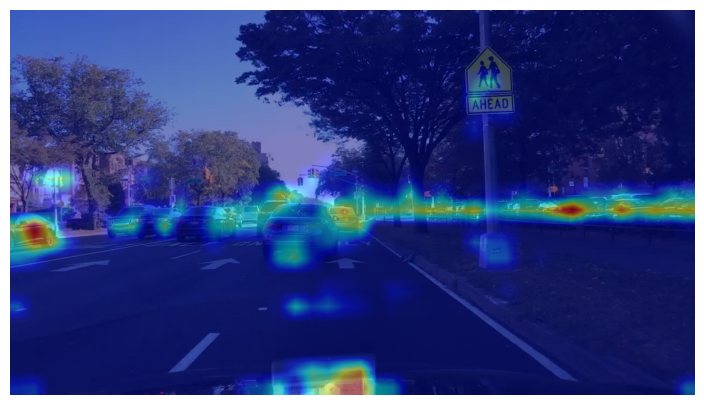

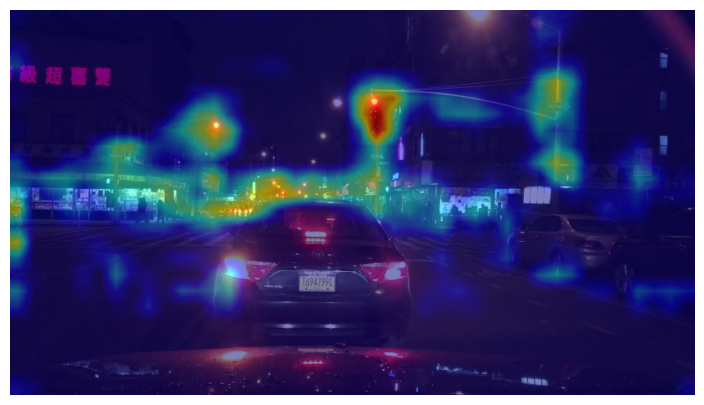

--- Grad-CAM: Stress Sample ---


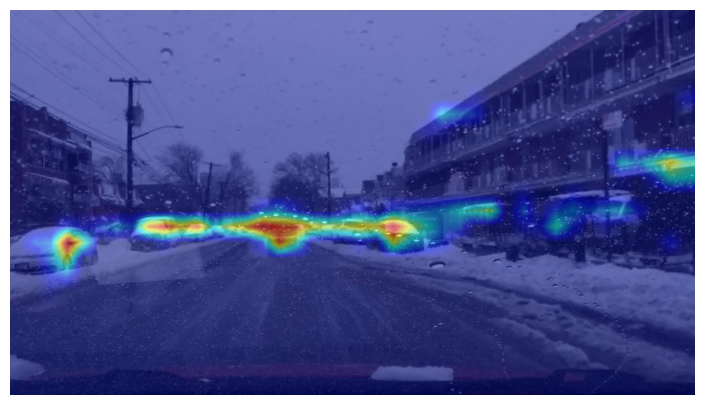

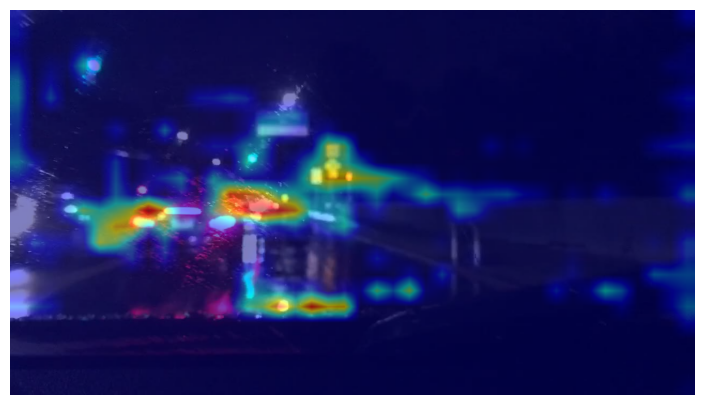

In [ ]:
!pip install -q grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import FasterRCNNBoxScoreTarget
import numpy as np, matplotlib.pyplot as plt, cv2
import torch

# Define target layer for Faster R-CNN (usually the last layer of the backbone)
target_layer = [model.backbone.body.layer4[-1]]
# target_layer = [model.backbone.body.layer3[-1]]  # more spatial detail
cam = GradCAM(model=model, target_layers=target_layer)

REVERSE_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

def show_gradcam(img_tensor, save_name):
    model.eval()
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(input_tensor)

    preds = outputs[0]
    score_threshold = 0.1 # Threshold to filter weak detections
    high_conf_indices = torch.where(preds['scores'] > score_threshold)[0]

    if high_conf_indices.numel() == 0:
        print(f"No detections above {score_threshold} for {save_name}. Showing raw image.")
        plt.imshow(img_tensor.permute(1,2,0).cpu().numpy()); plt.axis('off'); plt.show()
        return

    # Target the highest scoring detection
    top_idx = high_conf_indices[torch.argmax(preds['scores'][high_conf_indices])]
    # targets = [FasterRCNNBoxScoreTarget(labels=preds['labels'][top_idx:top_idx+1],bounding_boxes=preds['boxes'][top_idx:top_idx+1])]
    targets = [FasterRCNNBoxScoreTarget(labels=preds['labels'][high_conf_indices],bounding_boxes=preds['boxes'][high_conf_indices])]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    img_np = img_tensor.permute(1,2,0).cpu().numpy()
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(10,5))
    plt.imshow(cam_image)
    # plt.title(f"Grad-CAM: {REVERSE_LABEL_MAP.get(preds['labels'][top_idx].item(), 'object')}")

    plt.axis('off')
    plt.show()

print("--- Grad-CAM: Control Sample ---")
show_gradcam(control_test_ds[98][0], "control_cam.png")
show_gradcam(control_test_ds[10][0], "control_cam.png")

print("--- Grad-CAM: Stress Sample ---")
show_gradcam(stress_test_ds[1221][0], "stress_cam.png")
show_gradcam(stress_test_ds[596][0], "stress_cam.png")
# show_gradcam(stress_test_ds[976][0], "stress_cam.png")

In [ ]:
!pip install -q grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import FasterRCNNBoxScoreTarget
import numpy as np, matplotlib.pyplot as plt, cv2
import torch

# Define target layer for Faster R-CNN (usually the last layer of the backbone)
target_layer = [model.backbone.body.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

REVERSE_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

def show_gradcam(img_tensor, save_name):
    model.eval()
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(input_tensor)

    preds = outputs[0]
    score_threshold = 0.1 # Threshold to filter weak detections
    high_conf_indices = torch.where(preds['scores'] > score_threshold)[0]

    if high_conf_indices.numel() == 0:
        print(f"No detections above {score_threshold} for {save_name}. Showing raw image.")
        plt.imshow(img_tensor.permute(1,2,0).cpu().numpy()); plt.axis('off'); plt.show()
        return
    for idx in high_conf_indices:
        targets = [FasterRCNNBoxScoreTarget(
            labels=preds['labels'][idx:idx+1],
            bounding_boxes=preds['boxes'][idx:idx+1]
        )]

        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

        img_np = img_tensor.permute(1,2,0).cpu().numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

        cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

        plt.figure(figsize=(6,4))
        plt.imshow(cam_image)
        plt.title(f"Class: {REVERSE_LABEL_MAP.get(preds['labels'][idx].item(), 'object')} | Score: {preds['scores'][idx]:.2f}")
        plt.axis('off')
        plt.show()

print("--- Grad-CAM: Control Sample ---")
show_gradcam(control_test_ds[10][0], "control_cam.png")

print("--- Grad-CAM: Stress Sample ---")
# show_gradcam(stress_test_ds[1221][0], "stress_cam.png")
show_gradcam(stress_test_ds[596][0], "stress_cam.png")
show_gradcam(stress_test_ds[976][0], "stress_cam.png")

Visualizing Ground Truth Bounding Boxes...


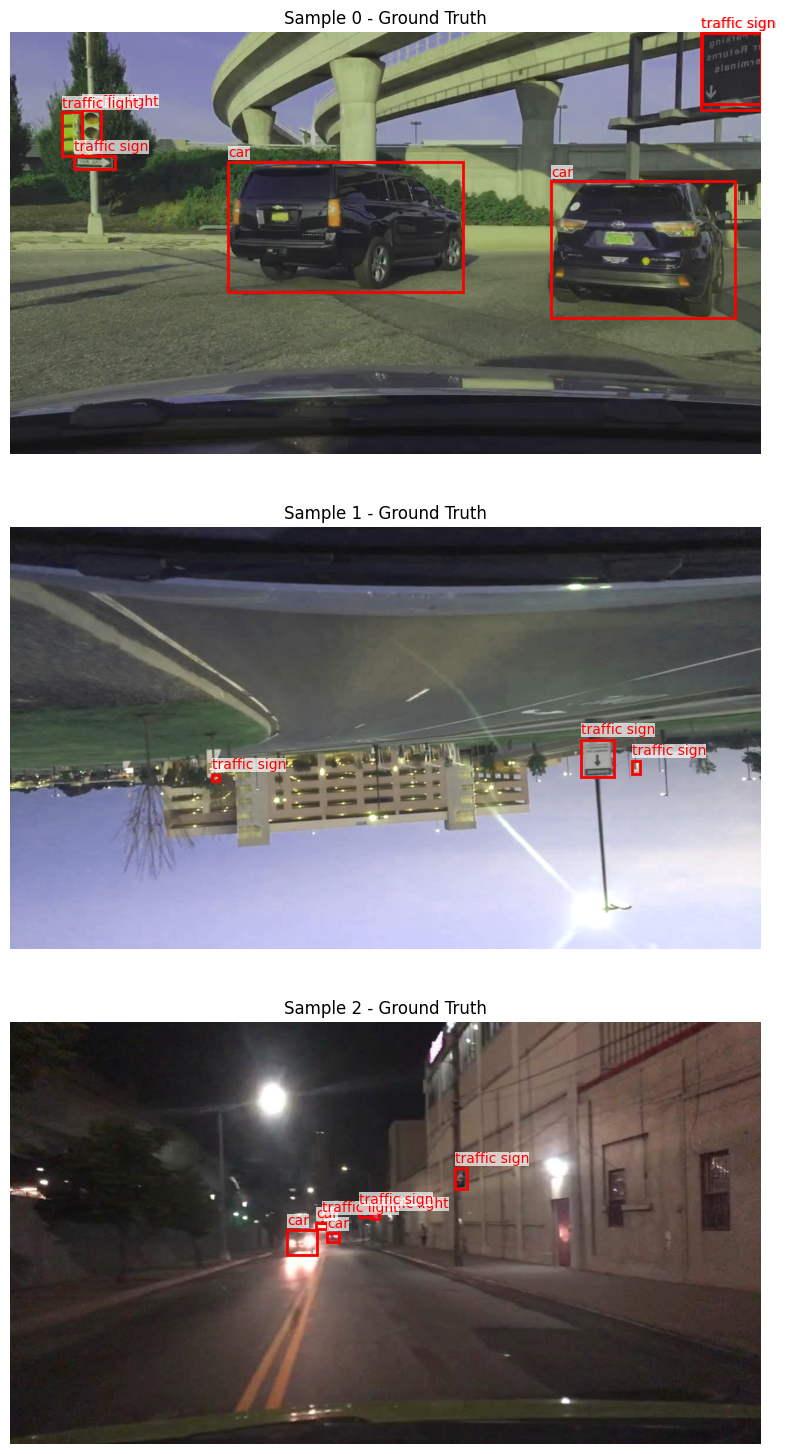

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_ground_truth(dataset, num_samples=3):
    REVERSE_LABEL_MAP[0] = "background" # Ensure background is mapped
    print("Visualizing Ground Truth Bounding Boxes...")
    fig, axes = plt.subplots(num_samples, 1, figsize=(8, 5 * num_samples))
    if num_samples == 1: # Handle single subplot case
        axes = [axes]

    for i in range(num_samples):
        img_tensor, target = dataset[i]
        img_np = img_tensor.permute(1, 2, 0).numpy() * 255
        img_np = img_np.astype(np.uint8)

        ax = axes[i]
        ax.imshow(img_np)
        ax.set_title(f"Sample {i} - Ground Truth")
        ax.axis('off')

        # Draw bounding boxes
        if len(target['boxes']) > 0:
            for box, label_idx in zip(target['boxes'], target['labels']):
                # Skip drawing dummy background box if it's the only one
                if label_idx.item() == 0 and len(target['boxes']) == 1:
                    continue

                x1, y1, x2, y2 = box.cpu().numpy()
                width = x2 - x1
                height = y2 - y1
                rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='r', facecolor='none')
                ax.add_patch(rect)

                label_name = REVERSE_LABEL_MAP.get(label_idx.item(), f"Unknown ({label_idx.item()})")
                ax.text(x1, y1 - 10, label_name, color='red', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0))
        else:
            ax.text(0, 0, "No objects (or only background) in ground truth", color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0))

    plt.tight_layout()
    plt.show()

# Visualize a few samples from the control training dataset
visualize_ground_truth(control_train_ds, num_samples=3)

In [ ]:
def attribution_iou(heatmap, boxes, threshold=0.5):
    h, w  = heatmap.shape
    bmap  = (heatmap > threshold).astype(int)
    gtmask = np.zeros((h, w), dtype=int)
    for box in boxes:
        x1, y1, x2, y2 = [int(v) for v in box]
        gtmask[max(0, y1):min(h, y2), max(0, x1):min(w, x2)] = 1
    inter = (bmap & gtmask).sum()
    union = (bmap | gtmask).sum()
    return inter / union if union > 0 else 0.0

def compute_mean_attr_iou(dataset, name, n=20):
    ious = []
    model.eval()

    for i, (img, tgt) in enumerate(dataset):
        if i >= n: break
        if len(tgt["boxes"]) == 0: continue

        input_tensor = img.unsqueeze(0).to(device)
        input_tensor.requires_grad_(True)

        # Get predictions to see if we have targets for Grad-CAM
        with torch.no_grad():
            outputs = model(input_tensor)

        if len(outputs[0]['boxes']) == 0:
            continue

        try:
            gt_boxes = tgt["boxes"].to(device)
            gt_labels = tgt["labels"].to(device)

            # Use the highest scoring GT-matched prediction as the target
            cam_targets = [FasterRCNNBoxScoreTarget(labels=gt_labels, bounding_boxes=gt_boxes)]

            # Compute Grad-CAM
            grayscale_cam = cam(input_tensor=input_tensor, targets=cam_targets)

            hm = cv2.resize(grayscale_cam[0], (img.shape[2], img.shape[1]))
            ious.append(attribution_iou(hm, gt_boxes.cpu().numpy()))
        except Exception:
            continue

    mean = np.mean(ious) if ious else 0.0
    print(f"Attribution IoU [{name}]: {mean:.4f}")
    return mean

# Run on a smaller subset for speed
ctrl_aiou   = compute_mean_attr_iou(control_test_ds, "Control", n=100)
stress_aiou = compute_mean_attr_iou(stress_test_ds,  "Stress",  n=100)
print(f"\nSummary:")
print(f"Control Attr-IoU: {ctrl_aiou:.4f}")
print(f"Stress Attr-IoU:  {stress_aiou:.4f}")
print(f"Attr-IoU Drop:    {ctrl_aiou - stress_aiou:.4f}")

Attribution IoU [Control]: 0.0000
Attribution IoU [Stress]: 0.0000

Summary:
Control Attr-IoU: 0.0000
Stress Attr-IoU:  0.0000
Attr-IoU Drop:    0.0000


In [ ]:


# Run on a smaller subset for speed
ctrl_aiou   = compute_mean_attr_iou(control_test_ds, "Control", n=400)
stress_aiou = compute_mean_attr_iou(stress_test_ds,  "Stress",  n=400)
print(f"\nSummary:")
print(f"Control Attr-IoU: {ctrl_aiou:.4f}")
print(f"Stress Attr-IoU:  {stress_aiou:.4f}")
print(f"Attr-IoU Drop:    {ctrl_aiou - stress_aiou:.4f}")

Attribution IoU [Control]: 0.0000
Attribution IoU [Stress]: 0.0000

Summary:
Control Attr-IoU: 0.0000
Stress Attr-IoU:  0.0000
Attr-IoU Drop:    0.0000


## Visualize

In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision.transforms.functional as F
import random


def plot_predictions_side_by_side(model, dataset, device, idx=None, score_thresh=0.5):
    model.eval()

    # Load image and target

    if idx is None:
      idx = random.randint(0, len(dataset) - 1)
    print(idx)
    img, target = dataset[idx]
    img_tensor = img.unsqueeze(0).to(device)

    # Forward pass
    with torch.no_grad():
        preds = model(img_tensor)[0]

    img_pil = F.to_pil_image(img).convert("RGB")

    # Create 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # =========================
    # LEFT: Ground Truth
    # =========================
    axes[0].imshow(img_pil)
    axes[0].set_title("Ground Truth")

    gt_boxes = target['boxes'].cpu().numpy()
    gt_labels = target.get('labels', None)

    for i, box in enumerate(gt_boxes):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor='g', facecolor='none')
        axes[0].add_patch(rect)

        if gt_labels is not None:
            axes[0].text(x1, y1-5, str(gt_labels[i].item()),
                         color='g', fontsize=12, weight='bold')

    axes[0].axis('off')

    # =========================
    # RIGHT: Predictions
    # =========================
    axes[1].imshow(img_pil)
    axes[1].set_title("Predictions")

    pred_boxes = preds['boxes'].cpu()
    scores = preds['scores'].cpu()
    pred_labels = preds['labels'].cpu()

    for box, score, label in zip(pred_boxes, scores, pred_labels):
        if score < score_thresh:
            continue

        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor='r', facecolor='none')
        axes[1].add_patch(rect)

        axes[1].text(x1, y2+5, f"{label.item()}:{score:.2f}",
                     color='r', fontsize=12, weight='bold')

    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

0


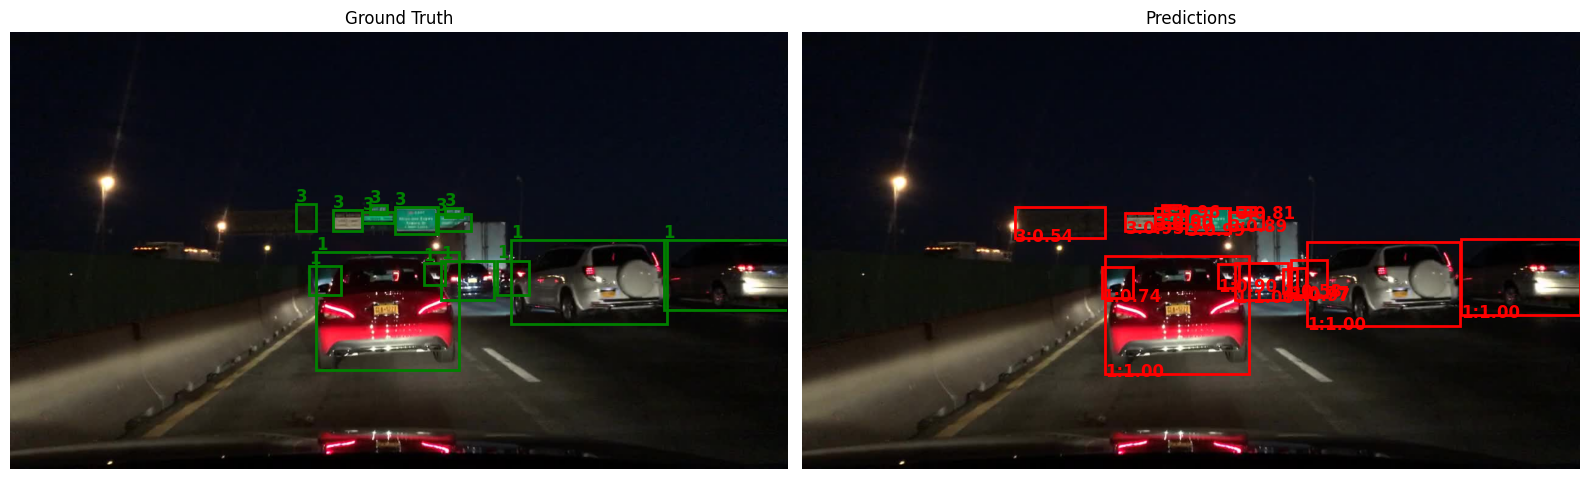

10


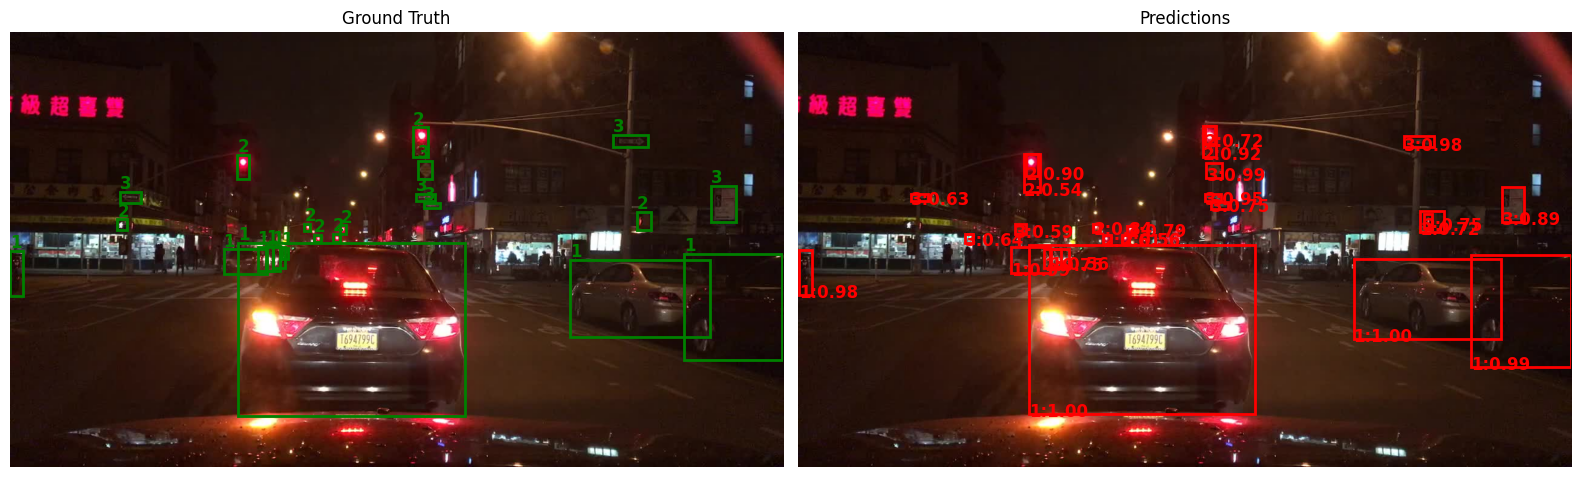

98


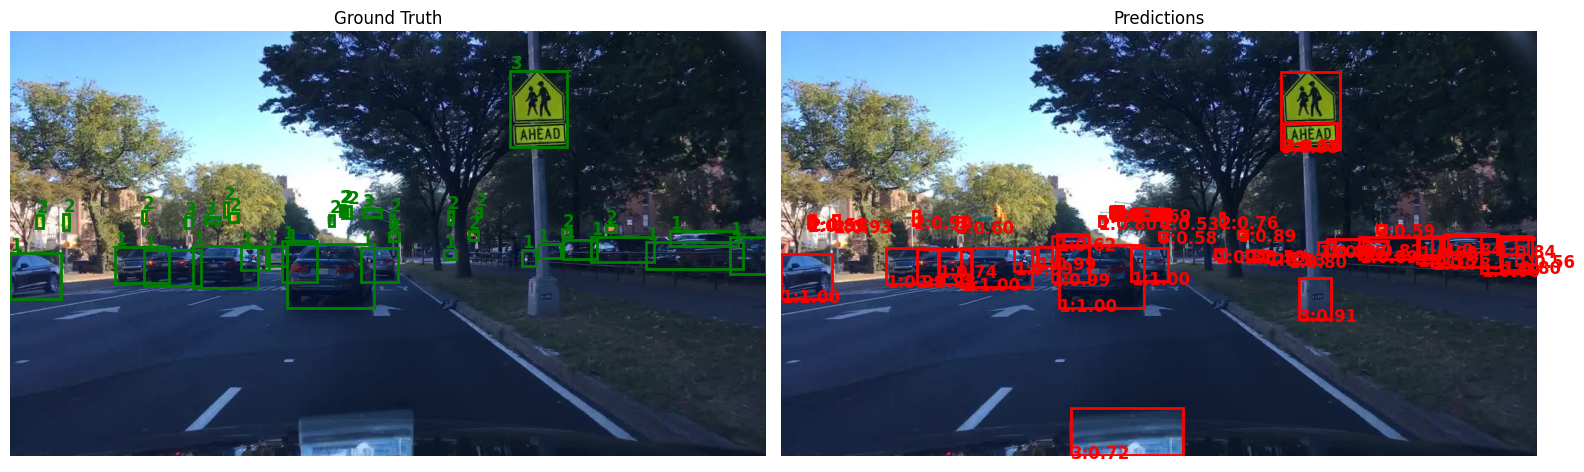

23


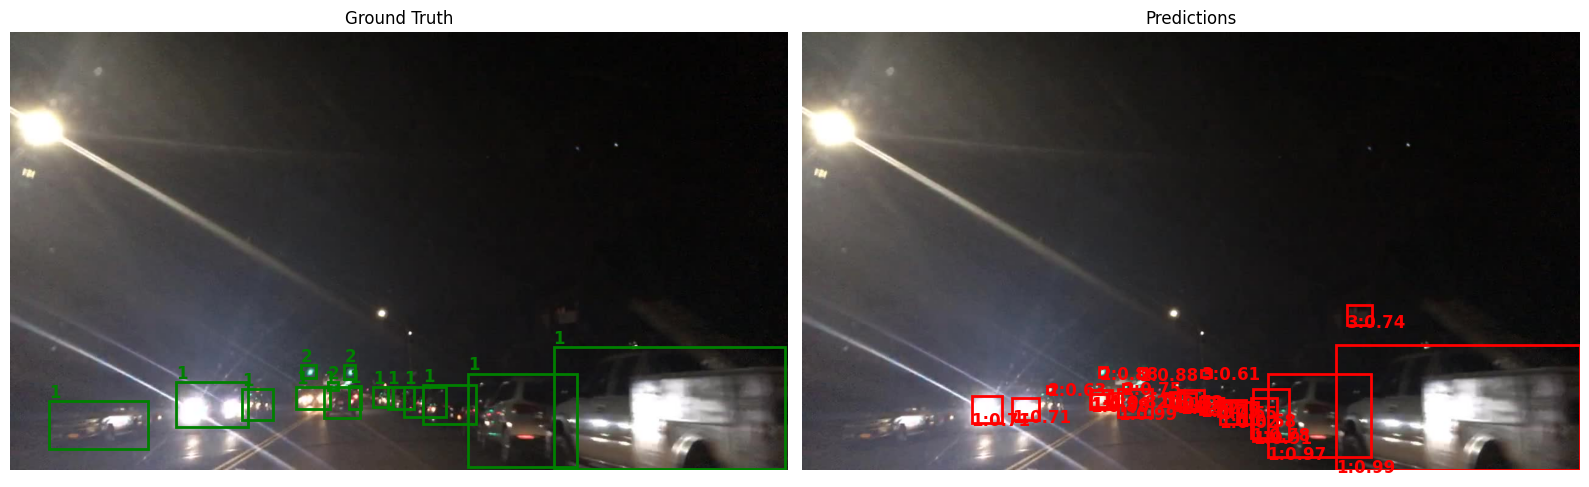

64


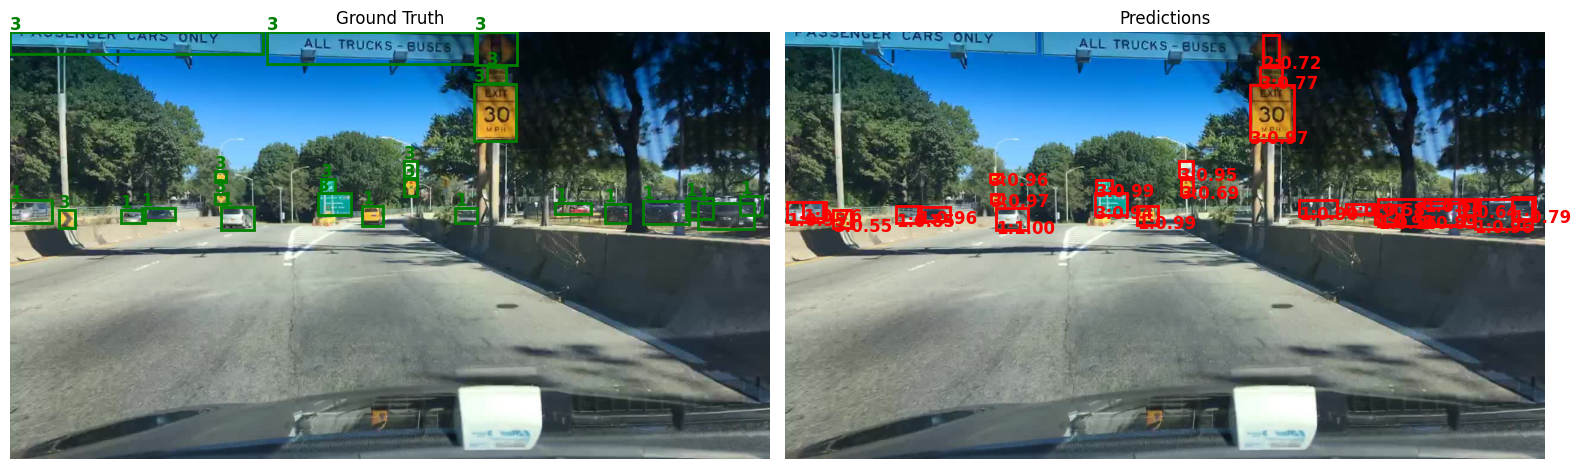

49


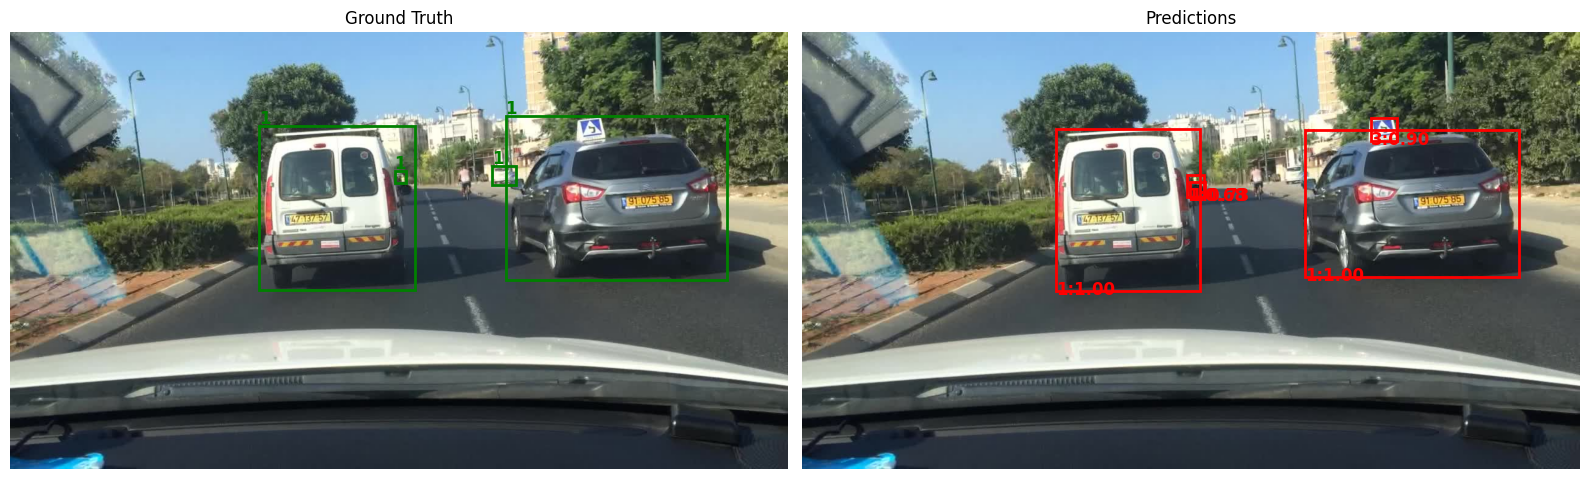

22


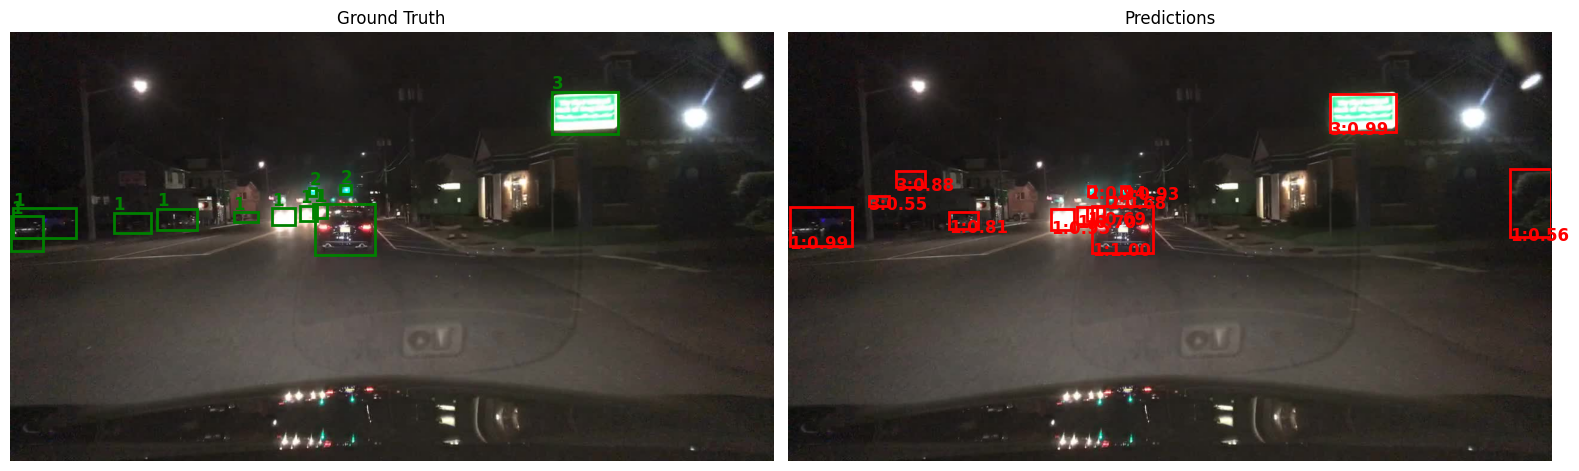

In [ ]:
# Visualize 5 random images from validation set
plot_predictions_side_by_side(model, control_test_ds, device,idx=0 ,score_thresh=0.5)
plot_predictions_side_by_side(model, control_test_ds, device,idx=10 ,score_thresh=0.5)
for i in range(5):
    # plot_predictions(model, control_test_ds, device, idx=i, score_thresh=0.5)
    plot_predictions_side_by_side(model, control_test_ds, device, score_thresh=0.5)

529


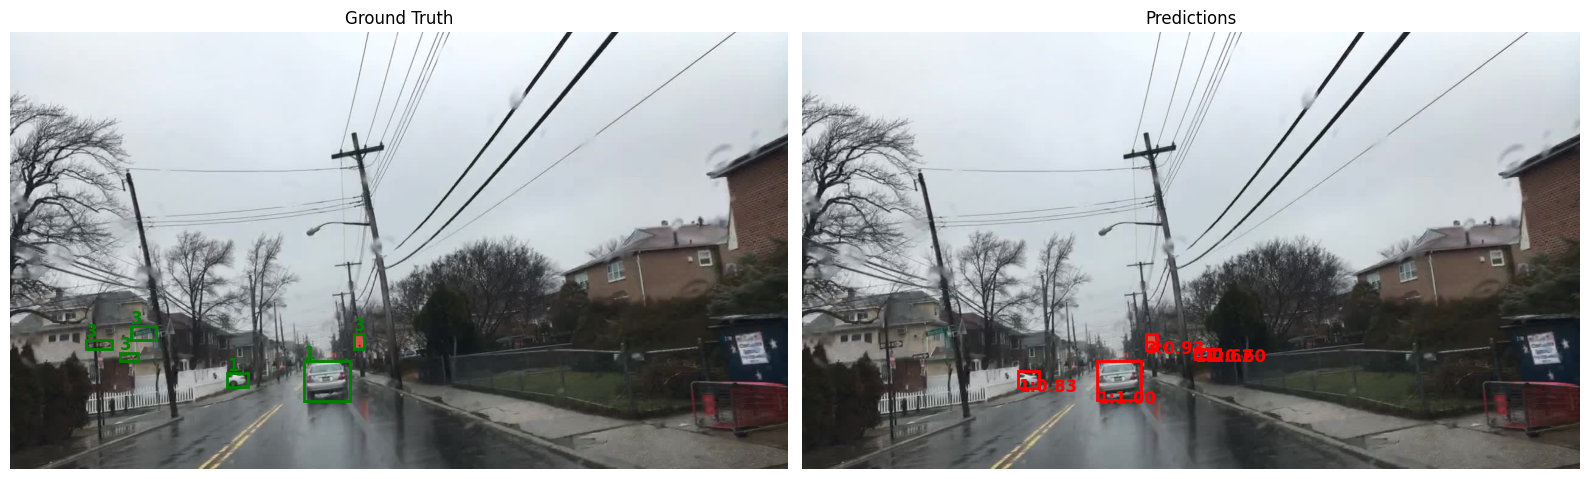

1221


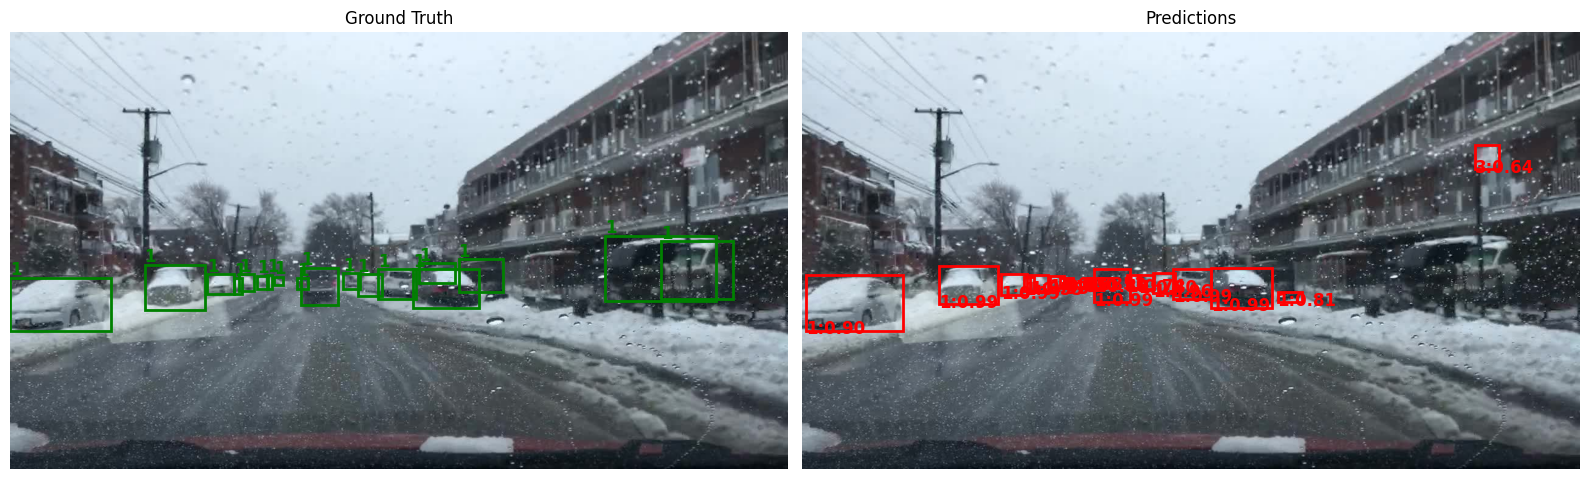

596


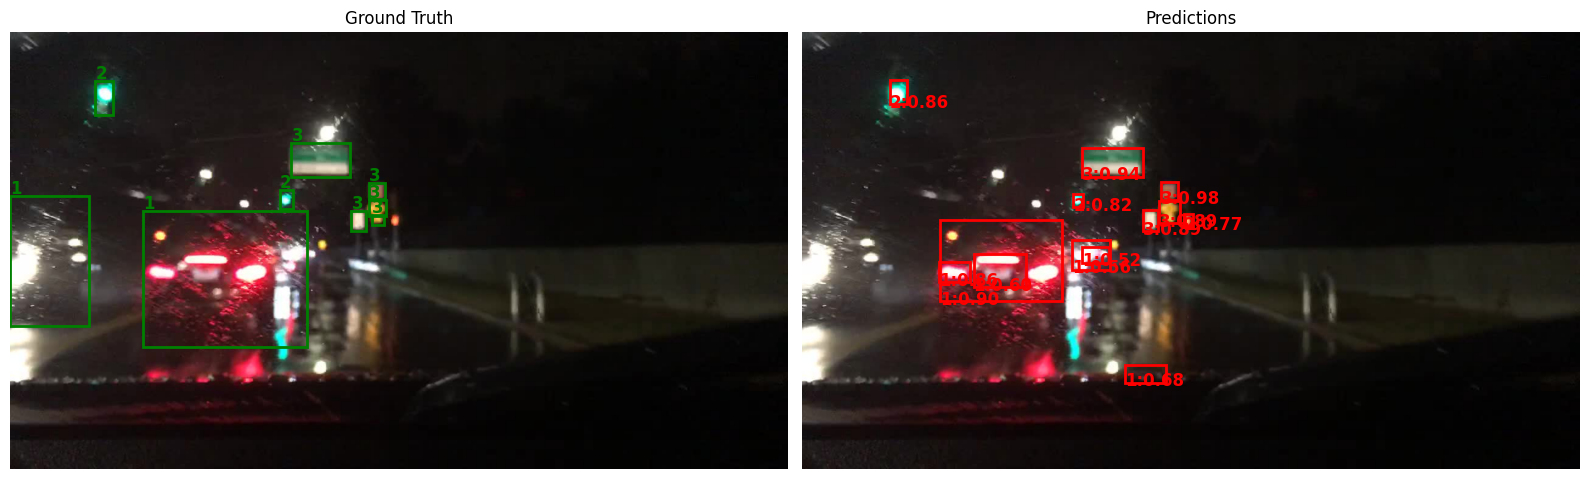

976


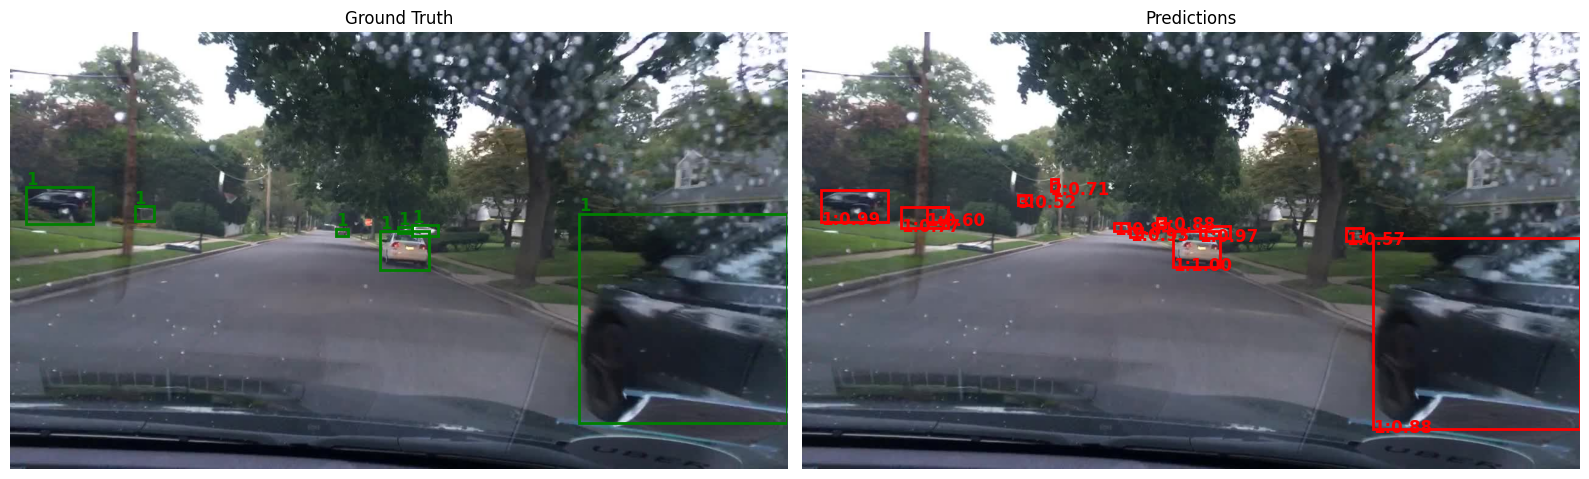

84


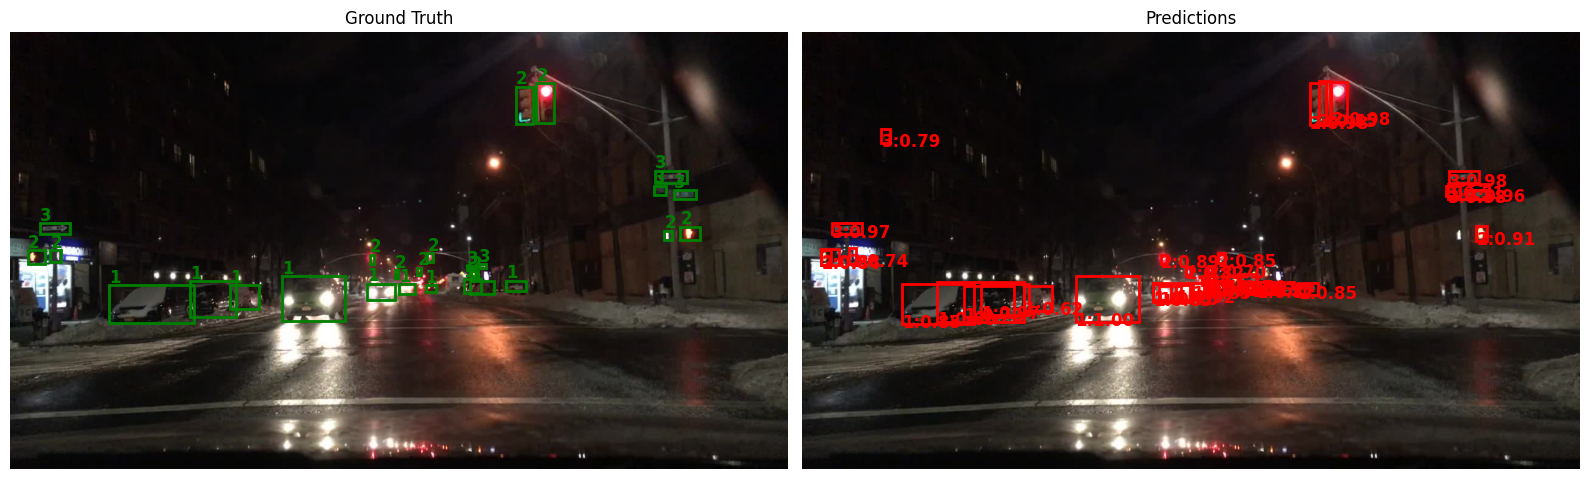

In [ ]:
# Visualize 5 random images from validation set
for i in range(5):
    # plot_predictions(model, stress_test_ds, device, idx=i, score_thresh=0.5)
    plot_predictions_side_by_side(model, stress_test_ds, device, idx=i, score_thresh=0.5)